# recs_032 — Eval metric history across every past run (read-only)

Reads **every** run directory under `artifacts/recs/offline_eval/runs/`, pulls each one's overall
metrics (retrieval-stage `eval_retrieval_overall.csv` and ranking-stage `eval_ranking_overall.csv`,
whichever exists), and lines them up chronologically -- so a metric's history for any method is
visible in one place, instead of comparing hand-picked runs from memory.

Chronology comes from each run's own `run_utc`/`created_utc` in its `*_run_meta.json`, not the
directory name -- some runs (`rag_v1`, `latest`, etc.) don't encode a timestamp in their name.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd
from IPython.display import display

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file())
RUNS_ROOT = REPO_ROOT / "artifacts/recs/offline_eval/runs"

RUN_DIRS = sorted(p for p in RUNS_ROOT.iterdir() if p.is_dir())
print(f"found {len(RUN_DIRS)} run directories")


found 22 run directories


## Load every run's overall tables

`retrieval_overall` = `eval_retrieval_overall.csv` (`k_retrieval`, isolated, no rerank).
`ranking_overall` = `eval_ranking_overall.csv` (`k_final`, includes rerank when the method is one).
Not every run has both -- ranking-only jobs (rerank on frozen pools) have no retrieval table.


In [2]:
def _run_timestamp(run_dir: Path) -> pd.Timestamp | None:
    for meta_name in ("eval_offline_run_meta.json", "eval_ranking_run_meta.json"):
        meta_path = run_dir / meta_name
        if meta_path.is_file():
            meta = json.loads(meta_path.read_text(encoding="utf-8"))
            ts = meta.get("run_utc") or meta.get("created_utc")
            if ts:
                return pd.Timestamp(ts)
    return None


def _n_examples(run_dir: Path) -> int | None:
    for meta_name, key in [
        ("eval_offline_run_meta.json", "n_examples_evaluable"),
        ("eval_ranking_run_meta.json", "n_examples_ranked"),
    ]:
        meta_path = run_dir / meta_name
        if meta_path.is_file():
            meta = json.loads(meta_path.read_text(encoding="utf-8"))
            if meta.get(key) is not None:
                return int(meta[key])
    return None


def _load_overall(run_dir: Path, filename: str, table_kind: str) -> pd.DataFrame | None:
    path = run_dir / filename
    if not path.is_file():
        return None
    df = pd.read_csv(path)
    df["run_id"] = run_dir.name
    df["run_ts"] = _run_timestamp(run_dir)
    df["n_examples"] = _n_examples(run_dir)
    df["table"] = table_kind
    return df


retrieval_frames = [df for d in RUN_DIRS if (df := _load_overall(d, "eval_retrieval_overall.csv", "retrieval")) is not None]
ranking_frames = [df for d in RUN_DIRS if (df := _load_overall(d, "eval_ranking_overall.csv", "ranking")) is not None]

retrieval_history = pd.concat(retrieval_frames, ignore_index=True).sort_values("run_ts")
ranking_history = pd.concat(ranking_frames, ignore_index=True).sort_values("run_ts")

print(f"retrieval_overall rows: {len(retrieval_history)} across {retrieval_history['run_id'].nunique()} runs")
print(f"ranking_overall rows:   {len(ranking_history)} across {ranking_history['run_id'].nunique()} runs")
print(f"runs missing a resolvable timestamp: {retrieval_history['run_ts'].isna().sum() + ranking_history['run_ts'].isna().sum()}")

n_examples_seen = sorted(retrieval_history["n_examples"].dropna().unique())
print(f"distinct cohort sizes seen across retrieval runs: {n_examples_seen}")
if len(n_examples_seen) > 1:
    print("  -> runs on a smaller/different cohort are NOT directly comparable point-to-point;")
    print("     the plot below marks them distinctly instead of overlaying them as equivalent.")


retrieval_overall rows: 108 across 19 runs
ranking_overall rows:   118 across 21 runs
runs missing a resolvable timestamp: 0
distinct cohort sizes seen across retrieval runs: [np.int64(200), np.int64(12500)]
  -> runs on a smaller/different cohort are NOT directly comparable point-to-point;
     the plot below marks them distinctly instead of overlaying them as equivalent.


## Retrieval-stage NDCG history, by method (one row per run, chronological)

In [3]:
retrieval_metric_label = "NDCG@K" if "NDCG@K" in retrieval_history.columns else "Hit@K"
pivot_retrieval = (
    retrieval_history
    .pivot_table(index=["run_ts", "run_id"], columns="method", values=retrieval_metric_label)
    .sort_index(level="run_ts")
)
pivot_retrieval_n = (
    retrieval_history
    .pivot_table(index=["run_ts", "run_id"], columns="method", values="n_examples", aggfunc="first")
    .sort_index(level="run_ts")
)
display(pivot_retrieval)


,method,fusion_c_raw_plus_behavior,multi_mean_train,popularity_train,rag_chunk_v1_query_plus_desc,rag_chunk_v1_raw_query,rag_chunk_v1_vector_blend_query,raw,two_tower_c_raw_plus_behavior,two_tower_v1,two_tower_v1_heuristic_logpop_blend,two_tower_v1_v2a_embed_query_logpop_blend
run_ts,run_id,,,,,,,,,,,
2026-05-09 15:19:08.666437+00:00,20260509_151908__baseline_retrieval,NaN,0.08328,0.15112,NaN,NaN,NaN,0.07168,NaN,NaN,NaN,NaN
2026-05-09 16:10:38.000769+00:00,20260509_161038__baseline_retrieval,NaN,0.08328,0.15112,NaN,NaN,NaN,0.07168,NaN,NaN,NaN,NaN
2026-05-10 16:21:26.427634+00:00,20260510_162126__baseline_retrieval,NaN,0.48592,0.76280,NaN,NaN,NaN,0.45296,NaN,NaN,NaN,NaN
2026-05-10 20:44:44.103329+00:00,20260510_204444__baseline_retrieval,NaN,0.48592,0.76280,NaN,NaN,NaN,0.45296,0.50632,NaN,NaN,NaN
2026-05-26 14:48:28.775913+00:00,20260526_144828__baseline_retrieval,0.50632,0.48592,0.76280,NaN,NaN,NaN,0.45296,NaN,0.27376,NaN,NaN
2026-05-27 00:45:35.316606+00:00,20260527_004535__baseline_retrieval,0.50632,0.48592,0.76280,NaN,NaN,NaN,0.45296,NaN,0.28592,NaN,NaN
2026-05-28 14:58:29.054991+00:00,20260528_145829__baseline_retrieval,0.50632,0.48592,0.76280,NaN,NaN,NaN,0.45296,NaN,0.51224,NaN,NaN
2026-05-29 03:02:10.174996+00:00,20260529_030210__baseline_retrieval,0.50632,0.48592,0.76280,NaN,NaN,NaN,0.45296,NaN,0.51224,NaN,NaN
2026-06-15 00:19:31.087606+00:00,20260615_001931__baseline_retrieval,0.50632,0.48592,0.76280,NaN,NaN,NaN,0.45296,NaN,0.51224,0.51224,NaN


## Ranking-stage NDCG history, by method

In [4]:
metric_r = "NDCG@K" if "NDCG@K" in ranking_history.columns else "Hit@K"
pivot_ranking = (
    ranking_history
    .pivot_table(index=["run_ts", "run_id"], columns="method", values=metric_r)
    .sort_index(level="run_ts")
)
display(pivot_ranking)


,method,fusion_c_raw_plus_behavior,multi_mean_train,popularity_train,rag_chunk_v1_query_plus_desc,rag_chunk_v1_raw_query,rag_chunk_v1_vector_blend_query,rag_chunk_v1_vector_blend_query_v2a_embed_query_logpop_blend,raw,two_tower_c_raw_plus_behavior,two_tower_v1,two_tower_v1_heuristic_logpop_blend,two_tower_v1_v2a_embed_query_logpop_blend
run_ts,run_id,,,,,,,,,,,,
2026-05-09 15:19:08.666437+00:00,20260509_151908__baseline_retrieval,NaN,0.037700,0.073109,NaN,NaN,NaN,NaN,0.035020,NaN,NaN,NaN,NaN
2026-05-09 16:10:38.000769+00:00,20260509_161038__baseline_retrieval,NaN,0.037700,0.073109,NaN,NaN,NaN,NaN,0.035020,NaN,NaN,NaN,NaN
2026-05-10 16:21:26.427634+00:00,20260510_162126__baseline_retrieval,NaN,0.037700,0.073109,NaN,NaN,NaN,NaN,0.035020,NaN,NaN,NaN,NaN
2026-05-10 20:44:44.103329+00:00,20260510_204444__baseline_retrieval,NaN,0.037700,0.073109,NaN,NaN,NaN,NaN,0.035020,0.038836,NaN,NaN,NaN
2026-05-26 14:48:28.775913+00:00,20260526_144828__baseline_retrieval,0.038836,0.037700,0.073109,NaN,NaN,NaN,NaN,0.035020,NaN,0.008915,NaN,NaN
2026-05-27 00:45:35.316606+00:00,20260527_004535__baseline_retrieval,0.038836,0.037700,0.073109,NaN,NaN,NaN,NaN,0.035020,NaN,0.008793,NaN,NaN
2026-05-28 14:58:29.054991+00:00,20260528_145829__baseline_retrieval,0.038836,0.037700,0.073109,NaN,NaN,NaN,NaN,0.035020,NaN,0.018161,NaN,NaN
2026-05-29 03:02:10.174996+00:00,20260529_030210__baseline_retrieval,0.038836,0.037700,0.073109,NaN,NaN,NaN,NaN,0.035020,NaN,0.018161,NaN,NaN
2026-06-15 00:19:31.087606+00:00,20260615_001931__baseline_retrieval,0.038836,0.037700,0.073109,NaN,NaN,NaN,NaN,0.035020,NaN,0.018161,0.092892,NaN


## Plot: NDCG@K over time for the methods that appear most often

Sparse cells (a method only run a handful of times) are expected -- not every method was
registered for every run.


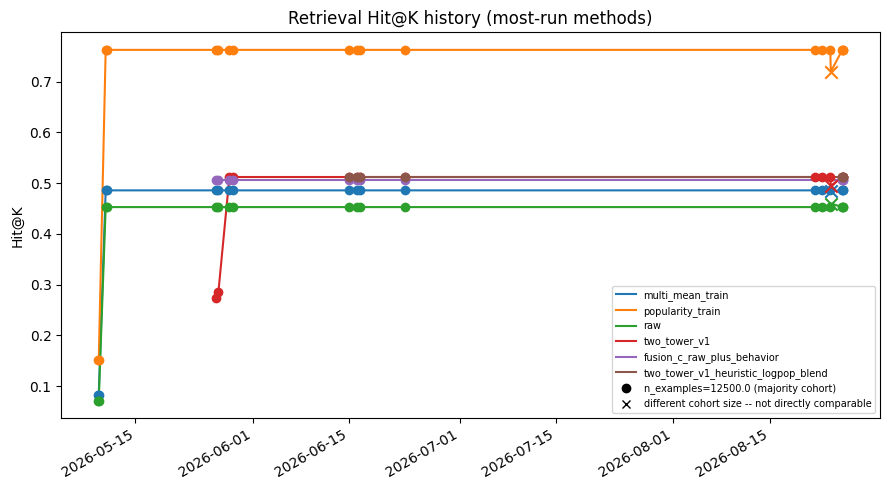

In [5]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

if plt is not None:
    majority_n = pivot_retrieval_n.stack().mode().iloc[0] if not pivot_retrieval_n.empty else None
    top_methods = pivot_retrieval.count().sort_values(ascending=False).head(6).index
    fig, ax = plt.subplots(figsize=(9, 5))
    for i, m in enumerate(top_methods):
        series = pivot_retrieval[m].dropna()
        n_for_series = pivot_retrieval_n[m].reindex(series.index)
        color = f"C{i}"
        ax.plot(series.index.get_level_values("run_ts"), series.values, "-", color=color, label=m, zorder=1)
        is_majority = n_for_series == majority_n
        ax.scatter(
            series.index.get_level_values("run_ts")[is_majority], series.values[is_majority],
            color=color, marker="o", zorder=2,
        )
        if (~is_majority).any():
            ax.scatter(
                series.index.get_level_values("run_ts")[~is_majority], series.values[~is_majority],
                color=color, marker="x", s=80, zorder=3,
            )
    ax.plot([], [], "ko", label=f"n_examples={majority_n} (majority cohort)")
    ax.plot([], [], "kx", label="different cohort size -- not directly comparable")
    ax.set_ylabel(retrieval_metric_label)
    ax.set_title(f"Retrieval {retrieval_metric_label} history (most-run methods)")
    ax.legend(fontsize=7, loc="lower right")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()
else:
    print("matplotlib not available; pivot tables above are enough.")


## Full raw table (all runs, all methods, all metrics)

For anything the pivots above don't show directly -- filter/sort this however's useful.


In [6]:
display(retrieval_history.sort_values(["run_ts", "method"]).reset_index(drop=True))


,method,Hit@K,Precision@K,Recall@K,run_id,run_ts,n_examples,table,ILD@10,CatalogCoverage@10,Novelty@10,PersonalizationGapVsPopularity@10
0,multi_mean_train,0.08328,0.008376,0.076479,20260509_151908__baseline_retrieval,2026-05-09 15:19:08.666437+00:00,12500,retrieval,NaN,NaN,NaN,NaN
1,popularity_train,0.15112,0.015184,0.146796,20260509_151908__baseline_retrieval,2026-05-09 15:19:08.666437+00:00,12500,retrieval,NaN,NaN,NaN,NaN
2,raw,0.07168,0.007216,0.066606,20260509_151908__baseline_retrieval,2026-05-09 15:19:08.666437+00:00,12500,retrieval,NaN,NaN,NaN,NaN
3,multi_mean_train,0.08328,0.008376,0.076479,20260509_161038__baseline_retrieval,2026-05-09 16:10:38.000769+00:00,12500,retrieval,NaN,NaN,NaN,NaN
4,popularity_train,0.15112,0.015184,0.146796,20260509_161038__baseline_retrieval,2026-05-09 16:10:38.000769+00:00,12500,retrieval,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
103,two_tower_v1,0.51224,0.005414,0.494053,latest,2026-08-25 14:00:50.078679+00:00,12500,retrieval,0.261639,0.987302,12.167556,0.995623
104,two_tower_v1_heuristic_logpop_blend,0.51224,0.005414,0.494053,20260825_140050__baseline_offline,2026-08-25 14:00:50.078679+00:00,12500,retrieval,0.204632,0.501587,6.272161,0.720097
105,two_tower_v1_heuristic_logpop_blend,0.51224,0.005414,0.494053,latest,2026-08-25 14:00:50.078679+00:00,12500,retrieval,0.204632,0.501587,6.272161,0.720097
106,two_tower_v1_v2a_embed_query_logpop_blend,0.51224,0.005414,0.494053,latest,2026-08-25 14:00:50.078679+00:00,12500,retrieval,0.202787,0.511111,6.296105,0.726256


In [7]:
display(ranking_history.sort_values(["run_ts", "method"]).reset_index(drop=True))


,method,Hit@K,Precision@K,Recall@K,MAP@K,NDCG@K,MRR,ILD@10,CatalogCoverage@10,Novelty@10,PersonalizationGapVsPopularity@10,run_id,run_ts,n_examples,table,OracleHit@K,OracleNDCG@K
0,multi_mean_train,0.08328,0.008376,0.076479,0.025349,0.037700,0.027358,0.146727,1.000000,9.798976,0.976841,20260509_151908__baseline_retrieval,2026-05-09 15:19:08.666437+00:00,12500,ranking,NaN,NaN
1,popularity_train,0.15112,0.015184,0.146796,0.050594,0.073109,0.052221,0.212335,0.034921,5.317471,0.000000,20260509_151908__baseline_retrieval,2026-05-09 15:19:08.666437+00:00,12500,ranking,NaN,NaN
2,raw,0.07168,0.007216,0.066606,0.024917,0.035020,0.026749,0.160723,1.000000,9.838045,0.979470,20260509_151908__baseline_retrieval,2026-05-09 15:19:08.666437+00:00,12500,ranking,NaN,NaN
3,multi_mean_train,0.08328,0.008376,0.076479,0.025349,0.037700,0.027358,0.146727,1.000000,9.798976,0.976841,20260509_161038__baseline_retrieval,2026-05-09 16:10:38.000769+00:00,12500,ranking,NaN,NaN
4,popularity_train,0.15112,0.015184,0.146796,0.050594,0.073109,0.052221,0.212335,0.034921,5.317471,0.000000,20260509_161038__baseline_retrieval,2026-05-09 16:10:38.000769+00:00,12500,ranking,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,rag_chunk_v1_vector_blend_query,0.10200,0.010280,0.095435,0.035890,0.050307,0.038319,0.171750,1.000000,9.079760,0.983432,rag_v3_ranking,2026-08-26 21:58:15.762602+00:00,12500,ranking,0.53168,0.51809
114,rag_chunk_v1_vector_blend_query_v2a_embed_quer...,0.18144,0.018336,0.173688,0.062113,0.088675,0.064518,0.208377,0.444444,6.192206,0.782842,rag_v3_ranking,2026-08-26 21:58:15.762602+00:00,12500,ranking,0.53168,0.51809
115,two_tower_v1,0.04680,0.004728,0.043740,0.010325,0.018161,0.011008,0.261639,0.987302,12.167556,0.995623,rag_v3_ranking,2026-08-26 21:58:15.762602+00:00,12500,ranking,0.51224,0.49831
116,two_tower_v1_heuristic_logpop_blend,0.19328,0.019560,0.184095,0.064321,0.092892,0.067059,0.204632,0.501587,6.272161,0.720097,rag_v3_ranking,2026-08-26 21:58:15.762602+00:00,12500,ranking,0.51224,0.49831
